# Exploratory data analysis

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Import data

In [2]:
df_returns = pd.read_csv('data/returns.csv')
# Convert columns to lowercase
df_returns.columns = [col.lower() for col in df_returns.columns]

df_kcal = pd.read_csv('data/kcal.csv')
df_kcal.columns = [col.lower() for col in df_kcal.columns]

df_recall = pd.read_csv('data/recall.csv')
df_recall.columns = [col.lower() for col in df_recall.columns]

df_group = pd.read_csv('data/groups.csv')
df_group.columns = [col.lower() for col in df_group.columns]

In [3]:
# make dates have some format
df_group['date'] = pd.to_datetime(df_group['date'], dayfirst=True)
df_returns['date'] = pd.to_datetime(df_returns['date'], dayfirst=True)

#df_group['date'] = df_group['date'].dt.strftime('%Y-%m-%d')
df_group.head()

/var/folders/7g/c1kcr6_s3rz5b1cdfg6ljfc40000gn/T/ipykernel_45542/474741966.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_returns['date'] = pd.to_datetime(df_returns['date'], dayfirst=True)


,date,id,group,date_depart,depart,date_arrive,arrive,activity,activity.type,time.out,total.minutes,precision
0,2018-08-02,1006,0,02/08/2018,17.42,02/08/2018,17.58,Palm wine,Foraging,0.16,16,Observed
1,2018-08-10,1006,0,10/08/2018,12.41,10/08/2018,13.48,Slingshot hunting,Foraging,1.07,67,Observed
2,2018-08-10,1006,0,10/08/2018,14.31,10/08/2018,14.45,Palm wine,Foraging,0.14,14,Observed
3,2018-08-17,1006,0,17/08/2018,10.55,17/08/2018,11.29,Slingshot hunting,Foraging,0.34,34,Observed
4,2018-08-14,1008,0,14/08/2018,10.08,14/08/2018,10.30,Garden,Foraging,0.22,22,Observed


In [28]:
# convert group and id to string
df_group['group'] = df_group['group'].astype(str)
df_group['id'] = df_group['id'].astype(str)

df_group_foraging = df_group[df_group['activity.type'] == 'Foraging']
df_group_foraging.head()

solo_foraging = df_group_foraging['group'] == "0"
id_if_true = df_group_foraging['date'].astype(str) + '_' + df_group_foraging['id']
id_if_false = df_group_foraging['date'].astype(str) + '_' + df_group_foraging['group'] # Assuming group is integer/float, convert to str

df_group_foraging['group_id'] = np.where(solo_foraging, id_if_true, id_if_false)

/var/folders/7g/c1kcr6_s3rz5b1cdfg6ljfc40000gn/T/ipykernel_45542/2668219064.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_group_foraging['group_id'] = np.where(solo_foraging, id_if_true, id_if_false)


In [29]:
df_group_foraging['group_id'].head()

0    2018-08-02_1006
1    2018-08-10_1006
2    2018-08-10_1006
3    2018-08-17_1006
4    2018-08-14_1008
Name: group_id, dtype: object

In [36]:
# get the number of unique ids within each group
df_group_foraging.groupby('group_id')['id'].nunique()

# make a new group dataframe with the group_id as the index, concatenate only the unique ids within each 
df_group_summary = df_group_foraging.groupby('group_id').agg({'id': lambda x: '_'.join(sorted([str(item) for item in x.unique()]))}).reset_index()

# get the number of unique ids within each group, split the ids into a list and count the number of unique ids

In [33]:
# get the number of unique ids within each group, split the ids into a list and count the number of unique ids
df_group_summary['id_count'] = df_group_summary['id'].apply(lambda x: len(x.split('_')))
df_group_summary

,id,id_count
group_id,,
2018-07-23_1,1007_1008_1009_1010_1016_1031_3077,7
2018-07-23_10,1007_1008_1009_1010_1011_1016,6
2018-07-23_1101,1101,1
2018-07-23_1102,1102,1
2018-07-23_1119,1119,1
...,...,...
2018-09-02_2038,2038,1
2018-09-02_4,1023_1028_1106_1116_2031_2039_2522_2544_3061_3117,10
2018-09-02_5,1009_1031_2538_2542_3142,5


<Axes: >

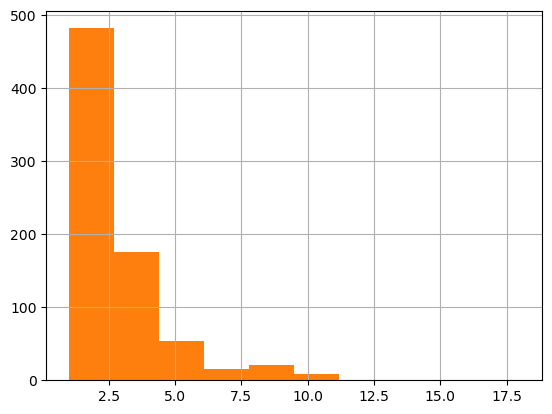

In [35]:
df_group_summary["id_count"].hist()
df_group_foraging.groupby('group_id')['id'].nunique().hist()

In [5]:
df_returns['net_food_weight_gram'].describe()

count     2514.000000
mean      2011.250322
std       3146.854832
min          0.900000
25%        300.000000
50%        900.000000
75%       2200.000000
max      27000.000000
Name: net_food_weight_gram, dtype: float64

In [6]:
df_kcal.head()

,index,yaka,english,processing_condition,kcal.g
0,1,Mobe,Unknown,whole,0.597857143
1,2,Maondo,Unknown,whole,0.224772727
2,3,Maika,Taro,Tuber without periderm,1.27
3,4,Dunda,Taro leaves,Leaves with petiole,0.234
4,5,Mbila,Palm nut,many fruits with bracts,2.97


In [7]:
df_returns.head()

,date,pooled_group,index,net_food_weight_gram,gift,id,article,state
0,2018-08-01,1.0,55,1100.0,0.0,1030,ediki,with inedible
1,2018-08-01,1.0,55,1100.0,0.0,2523,ediki,with inedible
2,2018-08-01,1.0,55,1100.0,0.0,1010,ediki,with inedible
3,2018-08-01,10.0,14,100.0,0.0,2513,ekule,ready-to-eat
4,2018-08-01,10.0,14,100.0,0.0,2039,ekule,ready-to-eat


In [8]:
df_recall.head()
df_recall.count()

date                    446
gift                    446
id                      446
pooled_group            446
article_consumed        446
quantity                446
x1_unit_weight_grams    446
index                   444
source                  446
total_weight_grams      446
dtype: int64

In [9]:
df_group.head()

,date,id,group,date_depart,depart,date_arrive,arrive,activity,activity.type,time.out,total.minutes,precision
0,2018-08-02,1006,0,02/08/2018,17.42,02/08/2018,17.58,Palm wine,Foraging,0.16,16,Observed
1,2018-08-10,1006,0,10/08/2018,12.41,10/08/2018,13.48,Slingshot hunting,Foraging,1.07,67,Observed
2,2018-08-10,1006,0,10/08/2018,14.31,10/08/2018,14.45,Palm wine,Foraging,0.14,14,Observed
3,2018-08-17,1006,0,17/08/2018,10.55,17/08/2018,11.29,Slingshot hunting,Foraging,0.34,34,Observed
4,2018-08-14,1008,0,14/08/2018,10.08,14/08/2018,10.30,Garden,Foraging,0.22,22,Observed


In [10]:
# Merge to get kcal as rate
df_merged = pd.merge(df_returns, df_kcal[['index', 'kcal.g']], on='index', how='left').merge(df_group[['date','id', 'total.minutes']], on=['id', 'date'], how='left')

In [11]:
df_merged.head()

,date,pooled_group,index,net_food_weight_gram,gift,id,article,state,kcal.g,total.minutes
0,2018-08-01,1.0,55,1100.0,0.0,1030,ediki,with inedible,0.1225,16.0
1,2018-08-01,1.0,55,1100.0,0.0,1030,ediki,with inedible,0.1225,2.0
2,2018-08-01,1.0,55,1100.0,0.0,1030,ediki,with inedible,0.1225,1.0
3,2018-08-01,1.0,55,1100.0,0.0,2523,ediki,with inedible,0.1225,25.0
4,2018-08-01,1.0,55,1100.0,0.0,2523,ediki,with inedible,0.1225,15.0


In [12]:
df_merged['kcal.g'] = pd.to_numeric(df_merged['kcal.g'], errors='coerce')
df_merged['kcal.g'].dtypes


dtype('float64')

<Axes: >

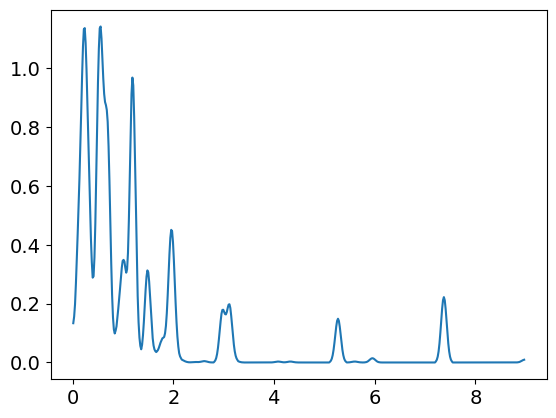

In [13]:
import arviz as az
az.plot_dist(df_merged['kcal.g'])

<Axes: >

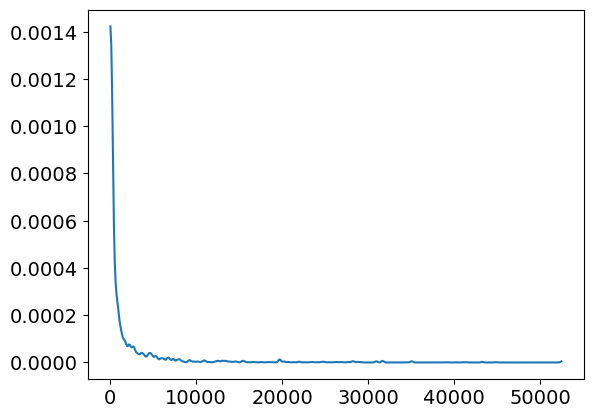

In [14]:
df_merged['kcal'] = df_merged['kcal.g'] * df_merged['net_food_weight_gram']

az.plot_dist(df_merged['kcal'])


In [15]:
df_merged['net_food_weight_gram'].describe()

count     4504.000000
mean      1776.892026
std       2921.912639
min          0.900000
25%        300.000000
50%        750.000000
75%       2000.000000
max      27000.000000
Name: net_food_weight_gram, dtype: float64

In [16]:
df_merged

,date,pooled_group,index,net_food_weight_gram,gift,id,article,state,kcal.g,total.minutes,kcal
0,2018-08-01,1.0,55,1100.0,0.0,1030,ediki,with inedible,0.1225,16.0,134.75
1,2018-08-01,1.0,55,1100.0,0.0,1030,ediki,with inedible,0.1225,2.0,134.75
2,2018-08-01,1.0,55,1100.0,0.0,1030,ediki,with inedible,0.1225,1.0,134.75
3,2018-08-01,1.0,55,1100.0,0.0,2523,ediki,with inedible,0.1225,25.0,134.75
4,2018-08-01,1.0,55,1100.0,0.0,2523,ediki,with inedible,0.1225,15.0,134.75
...,...,...,...,...,...,...,...,...,...,...,...
4499,2018-09-02,NaN,35,7100.0,0.0,1115,mela,ready-to-eat,1.1900,493.0,8449.00
4500,2018-09-02,NaN,35,8000.0,0.0,1116,mela,ready-to-eat,1.1900,512.0,9520.00
4501,2018-09-02,NaN,6,9375.0,0.0,2038,palm nut,with thorns,1.9440,367.0,18225.00
4502,2018-09-02,NaN,35,9500.0,0.0,1120,mela,ready-to-eat,1.1900,416.0,11305.00


In [34]:
df_merged.pooled_group.unique()

array([ 1., 10., 11.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 12., 13.,
       14., 15., 16., 17., 18., nan])

In [27]:
# convert date to datetime
df_merged['date'] = pd.to_datetime(df_merged['date'])


datetime64[ns]
